In [18]:
import numpy as np 
import matplotlib.pyplot as plt 


x=np.linspace(-5.0, 5.0, 100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y, -y])
x=np.hstack([x, -x])

In [19]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2 - x**2)
y1=np.hstack([y1, -y1])
x1=np.hstack([x, -x])

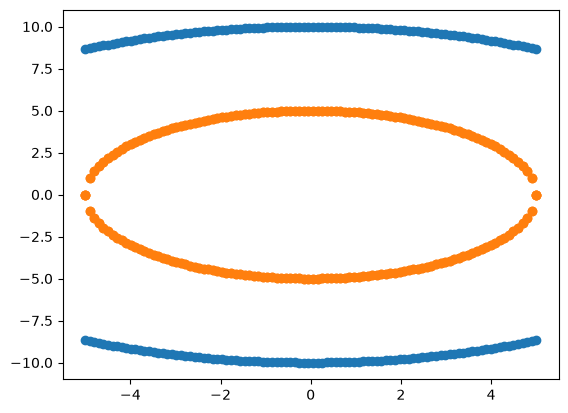

In [20]:
plt.scatter(x, y)
plt.scatter(x1, y1)

In [21]:
import pandas as pd 
df1=pd.DataFrame(np.vstack([y,x]).T, columns=['x1', 'x2'])
df1['y']=0
df2=pd.DataFrame(np.vstack([y1, x1]).T, columns=['x1', 'x2'])
df2['y']=1
df = pd.concat([df1, df2], ignore_index=True)

In [22]:
df.tail()

,x1,x2,y
595,-1.969049,4.59596,1
596,-1.714198,4.69697,1
597,-1.406908,4.79798,1
598,-0.999949,4.89899,1
599,-0.000000,5.00000,1


In [23]:
x=df.iloc[:, :2]
y=df.y

In [24]:
df['x1_square']=df['x1']**2
df['x2_square']=df['x2']**2
df['x1*x2']=df['x1']*df['x2']

In [27]:
x=df[['x1','x2','x1_square','x2_square','x1*x2']]
y=df['y']

In [28]:
x.head()

,x1,x2,x1_square,x2_square,x1*x2
0,8.660254,-5.00000,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,78.877155,21.122845,-40.818009


In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.25, random_state=10)

In [30]:
import plotly.express as px
fig=px.scatter_3d(df, x='x1',y='x2', z='x1*x2', color='y')
fig.show()

In [32]:
fig1=px.scatter_3d(df, x='x1_square', y='x1_square', z='x1*x2', color='y')
fig1.show()

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
classifier=SVC(kernel='linear')
classifier.fit(x_train, y_train)

y_pred=classifier.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

1.0
[[53  0]
 [ 0 97]]
